# Super-Resolution: реализация метода Максимова

Локальная версия ноутбука. Все промежуточные результаты (LR-кадры, выровненные
кадры, обученная модель, история обучения) сохраняются на диск, поэтому
повторно выполнять долгие ячейки не нужно — данные подгрузятся из кеша.

Чтобы пересчитать какой-то этап заново, удалите соответствующий файл в
`results/cache/` (или передайте `force=True` в `cached_compute`).

## Структура проекта

```
.
├── SRW.ipynb               (этот ноутбук)
├── data/
│   ├── test/base.png       (исходное HR-изображение)
│   └── DIV2K/              (датасет, скачивается автоматически)
├── models/                 (обученные модели)
└── results/
    ├── figures/            (PNG графиков)
    └── cache/              (pickle с промежуточными данными)
```


## 1. Сетап: импорты, пути, утилиты

In [13]:
from datetime import datetime
str(datetime.today().date())

'2026-05-08'

In [ ]:
# === Стандартная библиотека ===
import copy
import os
import pickle
import json
import time
import urllib.request
import zipfile
from pathlib import Path
from datetime import datetime

# === Третьи стороны ===
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# === Воспроизводимость ===
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# === Пути проекта (всё относительно папки с ноутбуком) ===
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "dataset"
TEST_DIR = DATA_DIR / "test"
DIV2K_DIR = DATA_DIR / "DIV2K"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"  / str(datetime.today().date())
CACHE_DIR = RESULTS_DIR / "cache" / str(datetime.today().date())

for d in (DATA_DIR, TEST_DIR, DIV2K_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# === Устройство ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"  Видеопамяти: {total_gb:.2f} GB")


# === Утилиты для кеша и сохранения графиков ===

def cached_compute(cache_name, compute_fn, *args, force=False, **kwargs):
    """
    Считает compute_fn(*args, **kwargs) и кеширует результат через pickle.
    При повторных вызовах загружает из кеша. Передайте force=True, чтобы
    пересчитать.

    cache_name: имя файла без расширения, относительно CACHE_DIR
    """
    cache_path = CACHE_DIR / f"{cache_name}.pkl"
    if cache_path.exists() and not force:
        print(f"[cache] Загружаем из {cache_path.name}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    print(f"[cache] Вычисляем {cache_name}...")
    result = compute_fn(*args, **kwargs)
    with open(cache_path, "wb") as f:
        pickle.dump(result, f)
    print(f"[cache] Сохранено в {cache_path.name}")
    return result


def save_fig(name, fig=None, dpi=120):
    """Сохраняет текущий (или переданный) график в FIGURES_DIR."""
    if fig is None:
        fig = plt.gcf()
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[fig] {path}")


print(f"Корень проекта: {PROJECT_ROOT}")


Устройство: cpu
Корень проекта: c:\Users\Anastasia\Desktop\Scientific-research-work


## 2. Загрузка опорного HR-кадра

Положите эталонную картинка в `data/test/base.png` используется
для генерации синтетических LR-кадров

HR-кадр загружен: (100, 200), dtype=uint8
[fig] c:\Users\Anastasia\Desktop\Scientific-research-work\results\figures\2026-05-08\01_hr_base.png


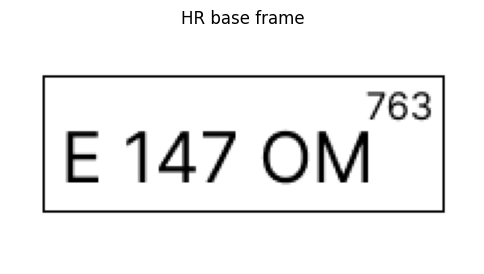

In [15]:
def load_hr_grayscale(image_path):
    """
    Загружает картинку и возвращает Y-канал (яркость) из YCbCr.
    Возвращает: numpy uint8, форма (H, W).
    """
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Не найдено: {image_path}")
    image_ycbcr = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
    return image_ycbcr[:, :, 0]


path_hr_frame = TEST_DIR / "base.png"
hr_frame = load_hr_grayscale(path_hr_frame)
print(f"HR-кадр загружен: {hr_frame.shape}, dtype={hr_frame.dtype}")

plt.figure(figsize=(6, 6))
plt.imshow(hr_frame, cmap="gray", vmin=0, vmax=255)
plt.title("HR base frame")
plt.axis("off")
save_fig("01_hr_base")
plt.show()


## 3. Генерация синтетических LR-кадров

Имитируем модель наблюдения камеры:
- субпиксельный сдвиг,
- размытие объективом (гаусс),
- уменьшение разрешения (дискретизация сенсором),
- шум сенсора.

In [16]:
def downscale(img, scale=0.25, method=cv2.INTER_AREA):
    """Уменьшает картинку. scale=0.25 = в 4 раза меньше."""
    h, w = img.shape[:2]
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    return cv2.resize(img, (new_w, new_h), interpolation=method)


def warp_affine_keep_size(img, tx, ty):
    """
    Чистый сдвиг (без поворота и масштаба) с сохранением размера.
    tx, ty могут быть дробными — это важно для субпиксельного сдвига.
    """
    h, w = img.shape[:2]
    M = np.array([[1.0, 0.0, tx],
                  [0.0, 1.0, ty]], dtype=np.float32)
    return cv2.warpAffine(
        img, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REFLECT,
    )


def apply_blur(img, blur_sigma):
    """Гауссово размытие. Имитирует PSF объектива."""
    kernel_size = int(2 * round(3 * blur_sigma) + 1)
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), blur_sigma)


def apply_noise(img, noise_std):
    """Аддитивный гауссов шум. Имитирует шум сенсора."""
    noise = np.random.normal(0, noise_std, img.shape)
    noisy = img.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)


def generate_synthetics(path_base_frame, count_frames, scale=0.25,
                        blur_sigma=1.0, noise_std=5.0, max_shift_lr=1.0):
    """
    Генерирует серию LR-кадров из одной HR-картинки.

    Возвращает:
        imgs:   список LR-кадров (первый — опорный, без сдвига)
        shifts: список реальных сдвигов в HR-пикселях
    """
    img_hr = cv2.imread(str(path_base_frame), cv2.IMREAD_GRAYSCALE)
    max_shift_hr = max_shift_lr / scale

    imgs, shifts = [], []

    # Опорный кадр — без сдвига, но с тем же blur/downscale/noise
    img_blurred = apply_blur(img_hr, blur_sigma)
    img_downscaled = downscale(img_blurred, scale=scale)
    img_noisy = apply_noise(img_downscaled, noise_std)
    imgs.append(img_noisy)
    shifts.append((0.0, 0.0))

    # Остальные — со случайными субпиксельными сдвигами
    for _ in range(count_frames):
        tx = np.random.uniform(-max_shift_hr, max_shift_hr)
        ty = np.random.uniform(-max_shift_hr, max_shift_hr)

        img_shifted = warp_affine_keep_size(img_hr, tx, ty)
        img_blurred = apply_blur(img_shifted, blur_sigma)
        img_downscaled = downscale(img_blurred, scale=scale)
        img_noisy = apply_noise(img_downscaled, noise_std)

        imgs.append(img_noisy)
        shifts.append((tx, ty))

    return imgs, shifts


[cache] Загружаем из lr_frames.pkl
Всего кадров: 4
Размер LR-кадра: (20, 40)
Сдвиги в HR-пикселях:
  Кадр 0: tx=+0.00, ty=+0.00
  Кадр 1: tx=-1.81, ty=+3.29
  Кадр 2: tx=-4.48, ty=+2.86
  Кадр 3: tx=-4.24, ty=+4.51
[fig] c:\Users\Anastasia\Desktop\Scientific-research-work\results\figures\2026-05-08\02_lr_frames.png


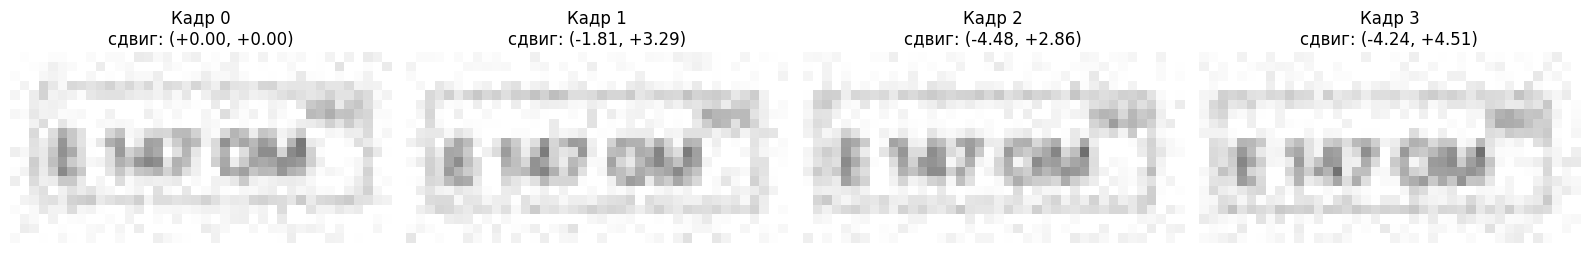

In [17]:
# Параметры пайплайна
NUM_FRAMES = 3
SCALE = 0.2
SCALE_FACTOR = int(round(1 / SCALE))  # 5
BLUR_SIGMA_GEN = 2.5
NOISE_STD_GEN = 10.0


def _generate():
    np.random.seed(SEED)  # фиксируем сдвиги
    return generate_synthetics(
        path_hr_frame,
        count_frames=NUM_FRAMES,
        scale=SCALE,
        blur_sigma=BLUR_SIGMA_GEN,
        noise_std=NOISE_STD_GEN,
        max_shift_lr=1.0,
    )


lr_frames, shifts = cached_compute("lr_frames", _generate)

print(f"Всего кадров: {len(lr_frames)}")
print(f"Размер LR-кадра: {lr_frames[0].shape}")
print("Сдвиги в HR-пикселях:")
for i, (tx, ty) in enumerate(shifts):
    print(f"  Кадр {i}: tx={tx:+.2f}, ty={ty:+.2f}")

# Визуализация
n = len(lr_frames)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(lr_frames[i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Кадр {i}\nсдвиг: ({shifts[i][0]:+.2f}, {shifts[i][1]:+.2f})")
    ax.axis("off")
plt.tight_layout()
save_fig("02_lr_frames")
plt.show()


## 4. Бикубическая интерполяция и карты ошибок

Каждый LR-кадр растягивается до HR-размера бикубиком. Карта ошибок —
норма градиента (оператор Собеля): чем резче переходы, тем больше ошибка
интерполяции в этой точке.

LR  3: (20, 40)
SR  3: (100, 200)
err 3: [1.00, 241.13]
[fig] c:\Users\Anastasia\Desktop\Scientific-research-work\results\figures\2026-05-08\03_bicubic_and_error_map.png


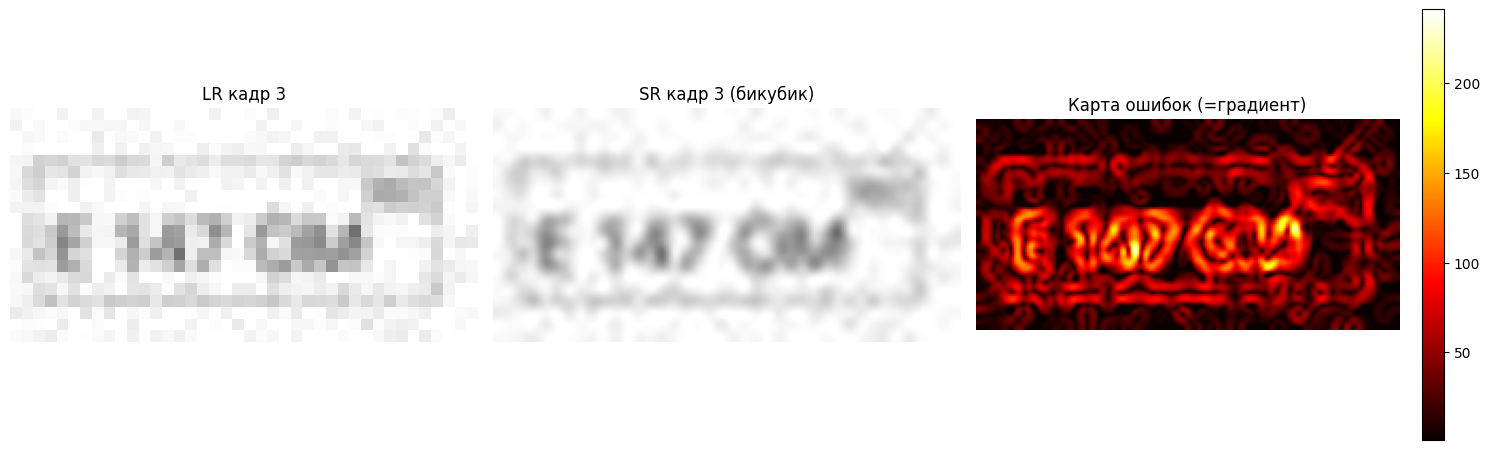

In [18]:
def upscale_bicubic(lr_img, scale_factor):
    """Бикубическая интерполяция LR -> HR-размер."""
    h, w = lr_img.shape[:2]
    return cv2.resize(lr_img, (w * scale_factor, h * scale_factor),
                      interpolation=cv2.INTER_CUBIC)


def compute_error_map_gradient(sr_img):
    """
    Простая карта ошибок: норма градиента (по Собелю).
    +1 в конце — чтобы исключить деление на ноль на следующих этапах.
    """
    img_float = sr_img.astype(np.float32)
    gx = cv2.Sobel(img_float, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img_float, cv2.CV_32F, 0, 1, ksize=3)
    return np.sqrt(gx ** 2 + gy ** 2) + 1.0


def baseline_step1(lr_frames, scale_factor):
    """Бикубик + карта ошибок для каждого LR-кадра."""
    sr_frames, error_maps = [], []
    for lr_img in lr_frames:
        sr = upscale_bicubic(lr_img, scale_factor)
        sr_frames.append(sr)
        error_maps.append(compute_error_map_gradient(sr))
    return sr_frames, error_maps


sr_frames, error_maps = baseline_step1(lr_frames, SCALE_FACTOR)

# Визуализация на одном кадре
demo_idx = min(3, len(lr_frames) - 1)
print(f"LR  {demo_idx}: {lr_frames[demo_idx].shape}")
print(f"SR  {demo_idx}: {sr_frames[demo_idx].shape}")
print(f"err {demo_idx}: [{error_maps[demo_idx].min():.2f}, {error_maps[demo_idx].max():.2f}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(lr_frames[demo_idx], cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"LR кадр {demo_idx}")
axes[0].axis("off")

axes[1].imshow(sr_frames[demo_idx], cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"SR кадр {demo_idx} (бикубик)")
axes[1].axis("off")

im = axes[2].imshow(error_maps[demo_idx], cmap="hot")
axes[2].set_title("Карта ошибок (=градиент)")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
save_fig("03_bicubic_and_error_map")
plt.show()


## 5. Геометрическое согласование (регистрация кадров)

Метод #9 из диссертации Максимова: ECC + проективное преобразование +
пирамидное огрубление (coarse-to-fine). При неудаче — фоллбэк на
фазовую корреляцию.

In [19]:
# =============================================================================
# Утилиты регистрации
# =============================================================================

def to_grayscale(img):
    """Конвертация в grayscale, если нужно."""
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()


def extract_transform_params(matrix, is_homography):
    """Извлекает интерпретируемые параметры из матрицы 2x3 / 3x3."""
    a, b, tx = matrix[0, 0], matrix[0, 1], matrix[0, 2]
    c, d, ty = matrix[1, 0], matrix[1, 1], matrix[1, 2]
    sx = np.sqrt(a ** 2 + c ** 2)
    sy = np.sqrt(b ** 2 + d ** 2)
    return {
        "translation_x": tx,
        "translation_y": ty,
        "scale_x": sx,
        "scale_y": sy,
        "scale_avg": (sx + sy) / 2,
        "rotation_deg": np.degrees(np.arctan2(c, a)),
    }


def compute_similarity(img1, img2):
    """MSE / PSNR / NCC между двумя изображениями."""
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
    f1 = img1.astype(np.float64)
    f2 = img2.astype(np.float64)
    mse = np.mean((f1 - f2) ** 2)
    psnr = 10 * np.log10(255 ** 2 / mse) if mse > 0 else float("inf")
    n1 = f1 - f1.mean()
    n2 = f2 - f2.mean()
    denom = np.sqrt(np.sum(n1 ** 2) * np.sum(n2 ** 2))
    ncc = np.sum(n1 * n2) / denom if denom > 0 else 0.0
    return {"mse": mse, "psnr": psnr, "ncc": ncc}


# =============================================================================
# ECC c пирамидой (coarse-to-fine)
# =============================================================================

def ecc_with_pyramid(ref_img, mov_img, warp_mode, criteria, num_levels=3):
    """
    ECC на пирамиде: сначала грубо на маленьком разрешении,
    потом уточняем на полном. Помогает при больших смещениях.
    """
    ref_pyr = [ref_img]
    mov_pyr = [mov_img]
    for _ in range(num_levels - 1):
        ref_pyr.append(cv2.pyrDown(ref_pyr[-1]))
        mov_pyr.append(cv2.pyrDown(mov_pyr[-1]))

    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        warp_matrix = np.eye(3, 3, dtype=np.float32)
    else:
        warp_matrix = np.eye(2, 3, dtype=np.float32)

    cc = 0.0
    for level in range(num_levels - 1, -1, -1):
        try:
            cc, warp_matrix = cv2.findTransformECC(
                ref_pyr[level], mov_pyr[level], warp_matrix, warp_mode, criteria
            )
        except cv2.error as e:
            if level == 0:
                raise ValueError(f"ECC не сошёлся: {e}")

        # Масштабирование сдвигов при переходе на более крупный уровень
        if level > 0:
            warp_matrix[0, 2] *= 2
            warp_matrix[1, 2] *= 2
            if warp_mode == cv2.MOTION_HOMOGRAPHY:
                warp_matrix[2, 0] /= 2
                warp_matrix[2, 1] /= 2

    return cc, warp_matrix


def register_images_ecc(ref_img, mov_img, num_iterations=300, termination_eps=1e-5):
    """
    Согласование mov_img с ref_img: ECC + пирамида + проективное преобразование.
    Метод #9 из диссертации Максимова.
    """
    ref_gray = to_grayscale(ref_img)
    mov_gray = to_grayscale(mov_img)

    if ref_gray.shape != mov_gray.shape:
        mov_gray = cv2.resize(mov_gray, (ref_gray.shape[1], ref_gray.shape[0]))

    warp_mode = cv2.MOTION_HOMOGRAPHY
    criteria = (
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        num_iterations,
        termination_eps,
    )

    # Нормализация диапазона + лёгкое размытие для устойчивости к шуму
    ref_norm = cv2.normalize(ref_gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.float32)
    mov_norm = cv2.normalize(mov_gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.float32)
    ref_blur = cv2.GaussianBlur(ref_norm, (3, 3), 0)
    mov_blur = cv2.GaussianBlur(mov_norm, (3, 3), 0)

    try:
        cc, warp_matrix = ecc_with_pyramid(
            ref_blur, mov_blur, warp_mode, criteria, num_levels=3
        )
    except (cv2.error, ValueError):
        print("  ВНИМАНИЕ: ECC не сошёлся, используем фазовую корреляцию")
        shift, response = cv2.phaseCorrelate(
            ref_blur.astype(np.float64), mov_blur.astype(np.float64)
        )
        warp_matrix = np.array([
            [1, 0, -shift[0]],
            [0, 1, -shift[1]],
            [0, 0, 1],
        ], dtype=np.float32)
        cc = response

    h, w = ref_gray.shape
    aligned = cv2.warpPerspective(
        mov_gray, warp_matrix, (w, h),
        flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
        borderMode=cv2.BORDER_REPLICATE,
    )

    info = extract_transform_params(warp_matrix, is_homography=True)
    info["correlation_coefficient"] = cc
    return aligned, warp_matrix, info


def apply_homography_to_image(img, warp_matrix, output_shape):
    """Применяет ту же матрицу, что и к кадру — полезно для карт ошибок."""
    h, w = output_shape
    return cv2.warpPerspective(
        img, warp_matrix, (w, h),
        flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
        borderMode=cv2.BORDER_REPLICATE,
    )


def align_frames_with_error_maps(sr_frames, error_maps):
    """
    Согласует все SR-кадры с первым (опорным).
    Той же матрицей выравнивает и карты ошибок.
    """
    reference = sr_frames[0]
    out_shape = reference.shape

    aligned_frames, aligned_errors, info_list = [], [], []
    for i in range(len(sr_frames)):
        if i == 0:
            aligned_frames.append(reference.copy())
            aligned_errors.append(error_maps[0].copy())
            info_list.append({"is_reference": True})
            continue

        aligned_img, warp_matrix, info = register_images_ecc(reference, sr_frames[i])
        aligned_err = apply_homography_to_image(error_maps[i], warp_matrix, out_shape)

        aligned_frames.append(aligned_img)
        aligned_errors.append(aligned_err)
        info_list.append(info)

    return aligned_frames, aligned_errors, info_list


In [20]:
# Запускаем регистрацию (с кешем)
def _register():
    return align_frames_with_error_maps(sr_frames, error_maps)


aligned_frames, aligned_error_maps, info_list = cached_compute(
    "aligned_frames", _register
)

# Печатаем найденные параметры
print("Найденные параметры трансформации:")
print(f"{'Кадр':<6}{'tx':<10}{'ty':<10}{'rot':<12}{'scale':<10}{'CC':<10}")
print("-" * 60)
for i, info in enumerate(info_list):
    if info.get("is_reference"):
        print(f"{i:<6}опорный")
        continue
    print(f"{i:<6}"
          f"{info['translation_x']:<10.3f}"
          f"{info['translation_y']:<10.3f}"
          f"{info['rotation_deg']:<12.4f}"
          f"{info['scale_avg']:<10.4f}"
          f"{info['correlation_coefficient']:<10.4f}")

print()
print("Сравнение с истинными сдвигами (знак может быть противоположным):")
print(f"{'Кадр':<6}{'Истинный':<25}{'Найденный':<25}")
print("-" * 60)
for i in range(1, len(shifts)):
    tr = shifts[i]
    fx = info_list[i].get("translation_x", 0)
    fy = info_list[i].get("translation_y", 0)
    print(f"{i:<6}({tr[0]:+.2f}, {tr[1]:+.2f})       ({fx:+.2f}, {fy:+.2f})")


[cache] Загружаем из aligned_frames.pkl
Найденные параметры трансформации:
Кадр  tx        ty        rot         scale     CC        
------------------------------------------------------------
0     опорный
1     -3.468    3.719     -0.4392     1.0025    0.9387    
2     -6.094    2.993     0.1007      1.0173    0.9430    
3     -6.180    4.544     -0.2722     1.0179    0.9192    

Сравнение с истинными сдвигами (знак может быть противоположным):
Кадр  Истинный                 Найденный                
------------------------------------------------------------
1     (-1.81, +3.29)       (-3.47, +3.72)
2     (-4.48, +2.86)       (-6.09, +2.99)
3     (-4.24, +4.51)       (-6.18, +4.54)


[fig] c:\Users\Anastasia\Desktop\Scientific-research-work\results\figures\2026-05-08\04_alignment.png


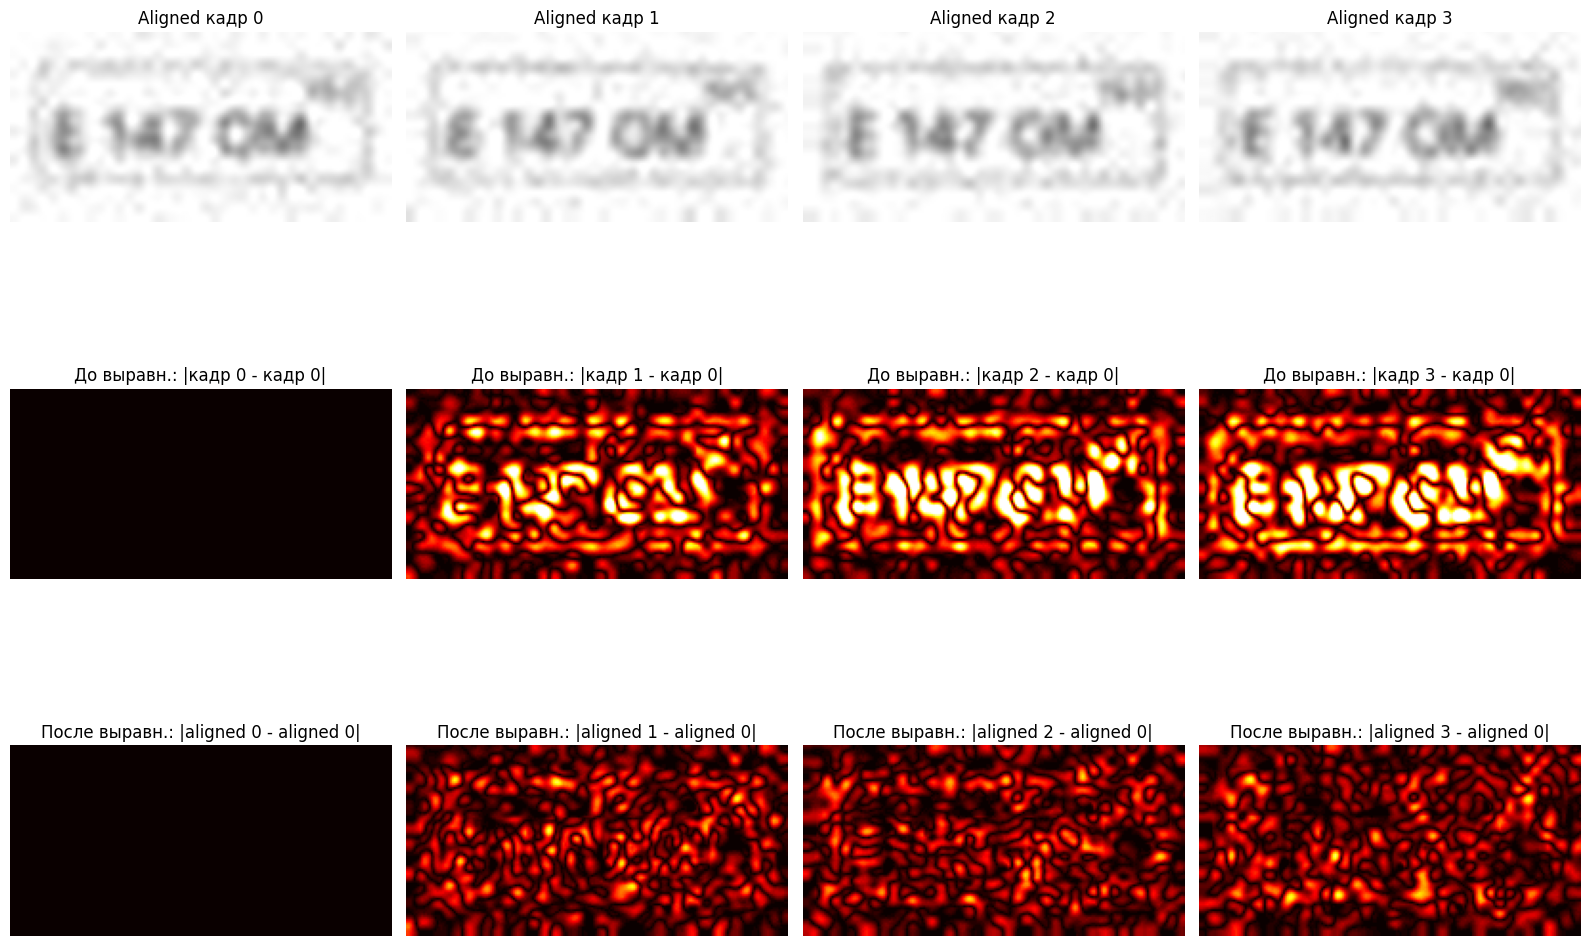

In [21]:
# Визуализация: до и после выравнивания
n = len(sr_frames)
fig, axes = plt.subplots(3, n, figsize=(4 * n, 12))
if n == 1:
    axes = axes.reshape(3, 1)

for i in range(n):
    axes[0, i].imshow(aligned_frames[i], cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Aligned кадр {i}")
    axes[0, i].axis("off")

    diff_before = np.abs(sr_frames[i].astype(np.float32) - sr_frames[0].astype(np.float32))
    axes[1, i].imshow(diff_before, cmap="hot", vmin=0, vmax=50)
    axes[1, i].set_title(f"До выравн.: |кадр {i} - кадр 0|")
    axes[1, i].axis("off")

    diff_after = np.abs(aligned_frames[i].astype(np.float32) - aligned_frames[0].astype(np.float32))
    axes[2, i].imshow(diff_after, cmap="hot", vmin=0, vmax=50)
    axes[2, i].set_title(f"После выравн.: |aligned {i} - aligned 0|")
    axes[2, i].axis("off")

plt.tight_layout()
save_fig("04_alignment")
plt.show()


In [22]:
# Метрики качества согласования (относительно опорного кадра)
print("Качество согласования:")
print(f"{'Кадр':<6}{'MSE до':<12}{'MSE после':<12}{'PSNR до':<12}{'PSNR после':<12}{'Δ PSNR':<10}")
print("-" * 70)
for i in range(1, len(sr_frames)):
    before = compute_similarity(sr_frames[0], sr_frames[i])
    after = compute_similarity(aligned_frames[0], aligned_frames[i])
    delta = after["psnr"] - before["psnr"]
    print(f"{i:<6}"
          f"{before['mse']:<12.2f}"
          f"{after['mse']:<12.2f}"
          f"{before['psnr']:<12.2f}"
          f"{after['psnr']:<12.2f}"
          f"{delta:+.2f} dB")


Качество согласования:
Кадр  MSE до      MSE после   PSNR до     PSNR после  Δ PSNR    
----------------------------------------------------------------------
1     287.83      93.55       23.54       28.42       +4.88 dB
2     450.21      88.03       21.60       28.68       +7.09 dB
3     522.22      90.80       20.95       28.55       +7.60 dB


## 6. Комплексирование

Формула 92 из диссертации Максимова: взвешенное среднее, где вес = 1 / дисперсия
ошибки в точке. Сравниваем с простым усреднением и одиночным бикубиком.

In [23]:
def fuse_optimal(aligned_frames, aligned_error_maps):
    """
    Оптимальное комплексирование (формула 92 у Максимова).
    Вес i-того кадра в точке = 1 / D_i, где D_i — карта ошибок.
    """
    frames_f = [f.astype(np.float64) for f in aligned_frames]
    errors_f = [e.astype(np.float64) for e in aligned_error_maps]

    numerator = np.zeros_like(frames_f[0])
    denominator = np.zeros_like(frames_f[0])
    for f, e in zip(frames_f, errors_f):
        weight = 1.0 / e
        numerator += f * weight
        denominator += weight

    # denominator > 0 гарантирован, т.к. в compute_error_map_gradient прибавили +1
    result = np.clip(numerator / denominator, 0, 255).astype(np.uint8)
    return result


def fuse_simple_average(aligned_frames):
    """Простое усреднение (контрольный вариант, без весов)."""
    frames_f = [f.astype(np.float64) for f in aligned_frames]
    avg = np.mean(frames_f, axis=0)
    return np.clip(avg, 0, 255).astype(np.uint8)


def compute_metrics(reference, result):
    """PSNR + SSIM. При несовпадении размеров подгоняет result под reference."""
    if reference.shape != result.shape:
        result = cv2.resize(result, (reference.shape[1], reference.shape[0]))
    psnr = peak_signal_noise_ratio(reference, result, data_range=255)
    ssim = structural_similarity(reference, result, data_range=255)
    return psnr, ssim


In [24]:
# Применяем оба варианта
result_optimal = fuse_optimal(aligned_frames, aligned_error_maps)
result_average = fuse_simple_average(aligned_frames)

# Эталон HR
hr_ref = cv2.cvtColor(cv2.imread(str(path_hr_frame)), cv2.COLOR_BGR2GRAY)
print(f"Размер HR (эталон): {hr_ref.shape}")
print(f"Размер результата:  {result_optimal.shape}")

if hr_ref.shape != result_optimal.shape:
    print("Подгоняем эталон под результат.")
    hr_ref = cv2.resize(hr_ref, (result_optimal.shape[1], result_optimal.shape[0]))

single_bicubic = aligned_frames[0]

psnr_single, ssim_single = compute_metrics(hr_ref, single_bicubic)
psnr_avg,    ssim_avg    = compute_metrics(hr_ref, result_average)
psnr_opt,    ssim_opt    = compute_metrics(hr_ref, result_optimal)

print()
print("Метрики (по сравнению с эталонным HR):")
print(f"{'Метод':<35}{'PSNR (dB)':<15}{'SSIM':<10}")
print("-" * 60)
print(f"{'Бикубик (одиночный кадр)':<35}{psnr_single:<15.2f}{ssim_single:<10.4f}")
print(f"{'Простое усреднение':<35}{psnr_avg:<15.2f}{ssim_avg:<10.4f}")
print(f"{'Оптимальное (Максимов)':<35}{psnr_opt:<15.2f}{ssim_opt:<10.4f}")

print()
print(f"Прирост PSNR от усреднения над одиночным:    {psnr_avg - psnr_single:+.2f} dB")
print(f"Прирост PSNR от оптимального над усреднением: {psnr_opt - psnr_avg:+.2f} dB")
print(f"Общий прирост (оптимальное над одиночным):    {psnr_opt - psnr_single:+.2f} dB")


Размер HR (эталон): (100, 200)
Размер результата:  (100, 200)

Метрики (по сравнению с эталонным HR):
Метод                              PSNR (dB)      SSIM      
------------------------------------------------------------
Бикубик (одиночный кадр)           13.96          0.4686    
Простое усреднение                 14.04          0.5120    
Оптимальное (Максимов)             14.05          0.5019    

Прирост PSNR от усреднения над одиночным:    +0.08 dB
Прирост PSNR от оптимального над усреднением: +0.01 dB
Общий прирост (оптимальное над одиночным):    +0.09 dB


[fig] c:\Users\Anastasia\Desktop\Scientific-research-work\results\figures\2026-05-08\05_fusion_comparison.png


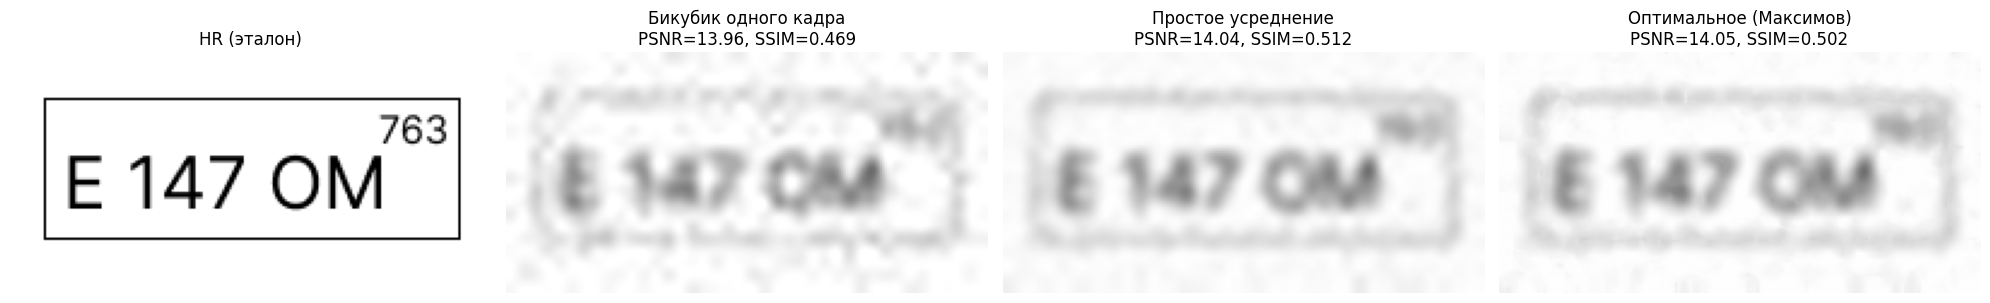

In [25]:
# Визуализация
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(hr_ref, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("HR (эталон)")
axes[0].axis("off")

axes[1].imshow(single_bicubic, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Бикубик одного кадра\nPSNR={psnr_single:.2f}, SSIM={ssim_single:.3f}")
axes[1].axis("off")

axes[2].imshow(result_average, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Простое усреднение\nPSNR={psnr_avg:.2f}, SSIM={ssim_avg:.3f}")
axes[2].axis("off")

axes[3].imshow(result_optimal, cmap="gray", vmin=0, vmax=255)
axes[3].set_title(f"Оптимальное (Максимов)\nPSNR={psnr_opt:.2f}, SSIM={ssim_opt:.3f}")
axes[3].axis("off")

plt.tight_layout()
save_fig("05_fusion_comparison")
plt.show()


## 7. Нейронные сети: предобученная EDSR


In [27]:
# !pip install super-image -q

from super_image import EdsrModel

NN_SCALE_FACTOR = 4  # super-image поддерживает 2/3/4

print("Загружаем предобученную EDSR (eugenesiow/edsr-base, 4x)...")
model_pretrained = EdsrModel.from_pretrained("eugenesiow/edsr-base", scale=NN_SCALE_FACTOR)
model_pretrained = model_pretrained.to(device)
model_pretrained.eval()

total_params = sum(p.numel() for p in model_pretrained.parameters())
print(f"Параметров в модели: {total_params:,}")


Загружаем предобученную EDSR (eugenesiow/edsr-base, 4x)...


https://huggingface.co/eugenesiow/edsr-base/resolve/main/pytorch_model_4x.pt
Параметров в модели: 1,517,595


In [28]:
def neural_network_upscale(lr_image, model, device):
    """
    Прогон ЧБ LR-кадра через SR-сеть (super-image ждёт RGB).

    lr_image: numpy uint8 (H, W)
    Возвращает: numpy uint8 (H*scale, W*scale)
    """
    # Дублируем ЧБ-канал → RGB, нормализуем в [0, 1], переводим в (1, 3, H, W)
    rgb = cv2.merge([lr_image, lr_image, lr_image])
    rgb_f = rgb.astype(np.float32) / 255.0
    rgb_chw = np.transpose(rgb_f, (2, 0, 1))
    inp = torch.from_numpy(rgb_chw).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(inp)

    out_arr = out.squeeze(0).cpu().numpy()        # (3, H', W')
    out_hwc = np.transpose(out_arr, (1, 2, 0))    # (H', W', 3)
    out_gray = out_hwc.mean(axis=2)               # обратно в ЧБ
    return np.clip(out_gray * 255.0, 0, 255).astype(np.uint8)


Прогоняем кадр через EDSR (предобученная)...
LR: (20, 40)  →  SR: (80, 160)

Метод                    PSNR (dB)      SSIM      
--------------------------------------------------
Бикубик                  15.42          0.4564    
EDSR (предобуч.)         15.91          0.4734    

Прирост PSNR от EDSR: +0.49 dB
[fig] c:\Users\Anastasia\Desktop\Scientific-research-work\results\figures\2026-05-08\06_edsr_pretrained.png


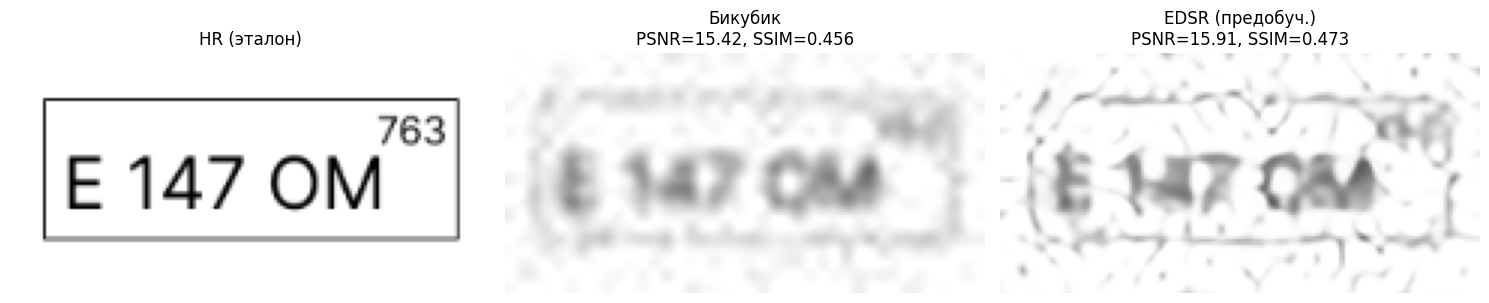

In [29]:
# Тест на одном LR-кадре
test_lr = lr_frames[0]

print("Прогоняем кадр через EDSR (предобученная)...")
sr_neural = neural_network_upscale(test_lr, model_pretrained, device)
print(f"LR: {test_lr.shape}  →  SR: {sr_neural.shape}")

# Сравнение с бикубиком и эталоном
sr_bicubic = cv2.resize(
    test_lr,
    (test_lr.shape[1] * NN_SCALE_FACTOR, test_lr.shape[0] * NN_SCALE_FACTOR),
    interpolation=cv2.INTER_CUBIC,
)

hr_ref_nn = cv2.cvtColor(cv2.imread(str(path_hr_frame)), cv2.COLOR_BGR2GRAY)
if hr_ref_nn.shape != sr_neural.shape:
    hr_ref_nn = cv2.resize(hr_ref_nn, (sr_neural.shape[1], sr_neural.shape[0]))

psnr_b, ssim_b = compute_metrics(hr_ref_nn, sr_bicubic)
psnr_n, ssim_n = compute_metrics(hr_ref_nn, sr_neural)

print()
print(f"{'Метод':<25}{'PSNR (dB)':<15}{'SSIM':<10}")
print("-" * 50)
print(f"{'Бикубик':<25}{psnr_b:<15.2f}{ssim_b:<10.4f}")
print(f"{'EDSR (предобуч.)':<25}{psnr_n:<15.2f}{ssim_n:<10.4f}")
print(f"\nПрирост PSNR от EDSR: {psnr_n - psnr_b:+.2f} dB")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(hr_ref_nn, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("HR (эталон)")
axes[0].axis("off")
axes[1].imshow(sr_bicubic, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Бикубик\nPSNR={psnr_b:.2f}, SSIM={ssim_b:.3f}")
axes[1].axis("off")
axes[2].imshow(sr_neural, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"EDSR (предобуч.)\nPSNR={psnr_n:.2f}, SSIM={ssim_n:.3f}")
axes[2].axis("off")
plt.tight_layout()
save_fig("06_edsr_pretrained")
plt.show()


## 8. Скачивание датасета DIV2K

Для дообучения нужны HR-картинки. Скачиваем DIV2K (train + valid HR).
~3.5 GB train + ~430 MB valid. Скачивается один раз; при повторном запуске
проверяется наличие файла.

In [30]:
HR_TRAIN_URL = "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip"
HR_VALID_URL = "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip"

hr_train_zip = DIV2K_DIR / "DIV2K_train_HR.zip"
hr_valid_zip = DIV2K_DIR / "DIV2K_valid_HR.zip"
train_extract_path = DIV2K_DIR / "DIV2K_train_HR"
valid_extract_path = DIV2K_DIR / "DIV2K_valid_HR"


def download_with_progress(url, save_path):
    """Скачивает файл с прогресс-баром, если ещё не скачан."""
    save_path = Path(save_path)
    if save_path.exists():
        size_mb = save_path.stat().st_size / (1024 ** 2)
        print(f"Уже скачан: {save_path.name} ({size_mb:.1f} MB)")
        return

    print(f"Скачиваем {url}\n  → {save_path}")
    with urllib.request.urlopen(url) as resp:
        total = int(resp.headers.get("Content-Length", 0))

    with tqdm(total=total, unit="B", unit_scale=True) as pbar:
        def hook(blocks_done, block_size, total_size):
            pbar.update(block_size)
        urllib.request.urlretrieve(url, save_path, reporthook=hook)
    print(f"Готово: {save_path.name}\n")


def extract_zip(zip_path, extract_to):
    """Распаковывает zip, если ещё не распакован."""
    extract_to = Path(extract_to)
    if extract_to.exists() and any(extract_to.iterdir()):
        n = len(list(extract_to.iterdir()))
        print(f"Уже распакован: {extract_to.name} ({n} файлов)")
        return

    print(f"Распаковываем {zip_path.name}...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(zip_path.parent)
    n = len(list(extract_to.iterdir()))
    print(f"Готово. Файлов: {n}\n")


download_with_progress(HR_TRAIN_URL, hr_train_zip)
download_with_progress(HR_VALID_URL, hr_valid_zip)

extract_zip(hr_train_zip, train_extract_path)
extract_zip(hr_valid_zip, valid_extract_path)

n_train = len(list(train_extract_path.iterdir()))
n_valid = len(list(valid_extract_path.iterdir()))
print(f"Train HR: {n_train} картинок")
print(f"Valid HR: {n_valid} картинок")


Скачиваем http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip
  → c:\Users\Anastasia\Desktop\Scientific-research-work\dataset\DIV2K\DIV2K_train_HR.zip


3.53GB [05:21, 11.0MB/s]                                


Готово: DIV2K_train_HR.zip

Скачиваем http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip
  → c:\Users\Anastasia\Desktop\Scientific-research-work\dataset\DIV2K\DIV2K_valid_HR.zip


449MB [00:21, 21.1MB/s]                              


Готово: DIV2K_valid_HR.zip

Распаковываем DIV2K_train_HR.zip...
Готово. Файлов: 800

Распаковываем DIV2K_valid_HR.zip...
Готово. Файлов: 100

Train HR: 800 картинок
Valid HR: 100 картинок


## 9. Датасет PyTorch для дообучения

Случайный патч из HR + наша модель искажений → пара (LR, HR).

In [31]:
def make_lr_frame(hr_image, shift_x, shift_y, scale_factor, blur_sigma, noise_std):
    """
    Один LR-кадр из HR-картинки. Удобная обёртка над warp/blur/downscale/noise.
    Используется в Dataset для обучения.
    """
    if shift_x != 0 or shift_y != 0:
        img = warp_affine_keep_size(hr_image, shift_x, shift_y)
    else:
        img = hr_image

    img = apply_blur(img, blur_sigma)
    img = downscale(img, scale=1.0 / scale_factor)
    img = apply_noise(img, noise_std)
    return img


class SuperResolutionDataset(Dataset):
    """
    Случайный квадратный патч из HR + наша модель искажений → (LR, HR) пара.
    Картинки конвертируются в ЧБ, потом дублируются в 3 канала, нормализуются в [0, 1].
    """

    def __init__(self, hr_folder, hr_patch_size=192, scale_factor=4,
                 blur_sigma=1.0, noise_std=5.0):
        self.hr_folder = Path(hr_folder)
        self.hr_patch_size = hr_patch_size
        self.scale_factor = scale_factor
        self.blur_sigma = blur_sigma
        self.noise_std = noise_std
        self.lr_patch_size = hr_patch_size // scale_factor

        self.image_files = sorted([
            p.name for p in self.hr_folder.iterdir()
            if p.suffix.lower() in (".png", ".jpg", ".jpeg")
        ])

        print(f"Dataset: {len(self.image_files)} картинок, "
              f"HR-патч {hr_patch_size}², LR-патч {self.lr_patch_size}²")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        hr_full = cv2.imread(str(self.hr_folder / self.image_files[index]),
                             cv2.IMREAD_GRAYSCALE)

        h, w = hr_full.shape
        y_start = np.random.randint(0, h - self.hr_patch_size + 1)
        x_start = np.random.randint(0, w - self.hr_patch_size + 1)

        hr_patch = hr_full[y_start:y_start + self.hr_patch_size,
                           x_start:x_start + self.hr_patch_size]

        lr_patch = make_lr_frame(
            hr_patch, shift_x=0, shift_y=0,
            scale_factor=self.scale_factor,
            blur_sigma=self.blur_sigma,
            noise_std=self.noise_std,
        )

        return self._to_tensor(lr_patch), self._to_tensor(hr_patch)

    @staticmethod
    def _to_tensor(gray_image):
        """ЧБ uint8 → RGB float32 (3, H, W) в [0, 1]."""
        rgb = cv2.merge([gray_image, gray_image, gray_image])
        rgb_f = rgb.astype(np.float32) / 255.0
        rgb_chw = np.transpose(rgb_f, (2, 0, 1))
        return torch.from_numpy(rgb_chw)


In [ ]:
# Параметры обучения
HR_PATCH_SIZE = 192
NN_SCALE_FACTOR = 4
TRAIN_BLUR_SIGMA = 1.0
TRAIN_NOISE_STD = 5.0

print("Train dataset:")
train_dataset = SuperResolutionDataset(
    hr_folder=train_extract_path,
    hr_patch_size=HR_PATCH_SIZE,
    scale_factor=NN_SCALE_FACTOR,
    blur_sigma=TRAIN_BLUR_SIGMA,
    noise_std=TRAIN_NOISE_STD,
)

print("\nValid dataset:")
valid_dataset = SuperResolutionDataset(
    hr_folder=valid_extract_path,
    hr_patch_size=HR_PATCH_SIZE,
    scale_factor=NN_SCALE_FACTOR,
    blur_sigma=TRAIN_BLUR_SIGMA,
    noise_std=TRAIN_NOISE_STD,
)

# Проверка одной пары
lr_t, hr_t = train_dataset[0]
print(f"\nLR tensor: {tuple(lr_t.shape)}, HR tensor: {tuple(hr_t.shape)}")
print(f"LR range: [{lr_t.min():.3f}, {lr_t.max():.3f}]")
print(f"HR range: [{hr_t.min():.3f}, {hr_t.max():.3f}]")

# Визуализация нескольких пар
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    lr_t, hr_t = train_dataset[i]
    axes[0, i].imshow(lr_t[0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"LR {i} {tuple(lr_t.shape[1:])}")
    axes[0, i].axis("off")
    axes[1, i].imshow(hr_t[0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"HR {i} {tuple(hr_t.shape[1:])}")
    axes[1, i].axis("off")
plt.tight_layout()
save_fig("07_train_pairs")
plt.show()


## 10. Дообучение EDSR

Если в `models/` уже лежит `edsr_finetuned.pth`, обучение пропускается и веса
просто загружаются. Чтобы переобучить — удалите файл или передайте `force=True`.

История обучения сохраняется в `results/cache/training_history.json`.

In [32]:
def train_one_model(model, train_dataset, valid_dataset, num_epochs,
                    batch_size=8, learning_rate=1e-4, save_path=None):
    """
    Дообучение SR-модели с валидацией по эпохам.
    Сохраняет веса лучшей по valid PSNR эпохи в save_path.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=2, pin_memory=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {"train_loss": [], "valid_loss": [], "valid_psnr": []}
    best_psnr = 0.0
    best_state = None

    print(f"Эпох: {num_epochs}, batch_size: {batch_size}, lr: {learning_rate}")
    print(f"Шагов в эпохе: {len(train_loader)}")
    print("-" * 70)

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # ---- TRAIN ----
        model.train()
        train_losses = []
        for lr_batch, hr_batch in train_loader:
            lr_batch = lr_batch.to(device)
            hr_batch = hr_batch.to(device)

            sr_batch = model(lr_batch)
            loss = criterion(sr_batch, hr_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        avg_train = float(np.mean(train_losses))

        # ---- VALID ----
        model.eval()
        valid_losses, valid_psnrs = [], []
        with torch.no_grad():
            for lr_batch, hr_batch in valid_loader:
                lr_batch = lr_batch.to(device)
                hr_batch = hr_batch.to(device)
                sr_batch = model(lr_batch)
                valid_losses.append(criterion(sr_batch, hr_batch).item())

                sr_clamped = torch.clamp(sr_batch, 0, 1)
                mse = ((sr_clamped - hr_batch) ** 2).mean(dim=[1, 2, 3])
                psnr = 10 * torch.log10(1.0 / (mse + 1e-10))
                valid_psnrs.extend(psnr.cpu().numpy().tolist())

        avg_valid = float(np.mean(valid_losses))
        avg_psnr = float(np.mean(valid_psnrs))
        history["train_loss"].append(avg_train)
        history["valid_loss"].append(avg_valid)
        history["valid_psnr"].append(avg_psnr)

        epoch_time = time.time() - epoch_start
        print(f"Эпоха {epoch+1:2d}/{num_epochs}: "
              f"train={avg_train:.4f}, valid={avg_valid:.4f}, "
              f"PSNR={avg_psnr:.2f} dB, time={epoch_time:.0f}s")

        if avg_psnr > best_psnr:
            best_psnr = avg_psnr
            best_state = copy.deepcopy(model.state_dict())
            if save_path is not None:
                torch.save(best_state, save_path)

    print("-" * 70)
    print(f"Готово. Лучший valid PSNR: {best_psnr:.2f} dB")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [34]:
# === Параметры дообучения ===
NUM_EPOCHS = 15
BATCH_SIZE = 20
LEARNING_RATE = 3e-5

model_save_path = MODELS_DIR / "edsr_finetuned.pth"
history_path = CACHE_DIR / "training_history.json"


def _train():
    """Обучает с нуля. Вызывается только если нет сохранённого чекпоинта."""
    print("Загружаем предобученную EDSR...")
    base_model = EdsrModel.from_pretrained("eugenesiow/edsr-base", scale=NN_SCALE_FACTOR)
    base_model = base_model.to(device)

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    trained, hist = train_one_model(
        model=base_model,
        train_dataset=train_dataset,
        valid_dataset=valid_dataset,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        save_path=str(model_save_path),
    )
    with open(history_path, "w") as f:
        json.dump(hist, f, indent=2)
    return trained, hist


if model_save_path.exists() and history_path.exists():
    print(f"Найдены готовые веса: {model_save_path}")
    print(f"Найдена история обучения: {history_path}")
    print("Загружаем без переобучения. Чтобы пересчитать — удалите эти два файла.")
    model_finetuned = EdsrModel.from_pretrained("eugenesiow/edsr-base", scale=NN_SCALE_FACTOR)
    model_finetuned.load_state_dict(torch.load(model_save_path, map_location=device))
    model_finetuned = model_finetuned.to(device)
    model_finetuned.eval()
    with open(history_path) as f:
        history = json.load(f)
else:
    model_finetuned, history = _train()
    model_finetuned.eval()

print("\nДообученная модель готова к использованию.")


Загружаем предобученную EDSR...
https://huggingface.co/eugenesiow/edsr-base/resolve/main/pytorch_model_4x.pt


NameError: name 'train_dataset' is not defined

In [ ]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train", marker="o")
axes[0].plot(history["valid_loss"], label="Valid", marker="s")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("L1 Loss")
axes[0].set_title("Loss во время обучения")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["valid_psnr"], color="green", marker="o")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("Valid PSNR во время обучения")
axes[1].grid(True)

plt.tight_layout()
save_fig("08_training_curves")
plt.show()

print(f"Стартовый PSNR: {history['valid_psnr'][0]:.2f} dB")
print(f"Финальный PSNR: {history['valid_psnr'][-1]:.2f} dB")
print(f"Улучшение:      {history['valid_psnr'][-1] - history['valid_psnr'][0]:+.2f} dB")


## 11. Итоговое сравнение: бикубик vs предобуч. EDSR vs дообуч. EDSR

In [ ]:
sr_bicubic = cv2.resize(
    test_lr,
    (test_lr.shape[1] * NN_SCALE_FACTOR, test_lr.shape[0] * NN_SCALE_FACTOR),
    interpolation=cv2.INTER_CUBIC,
)
sr_pretrained = neural_network_upscale(test_lr, model_pretrained, device)
sr_finetuned  = neural_network_upscale(test_lr, model_finetuned,  device)

hr_ref_cmp = cv2.cvtColor(cv2.imread(str(path_hr_frame)), cv2.COLOR_BGR2GRAY)
if hr_ref_cmp.shape != sr_finetuned.shape:
    hr_ref_cmp = cv2.resize(hr_ref_cmp, (sr_finetuned.shape[1], sr_finetuned.shape[0]))

psnr_b, ssim_b = compute_metrics(hr_ref_cmp, sr_bicubic)
psnr_p, ssim_p = compute_metrics(hr_ref_cmp, sr_pretrained)
psnr_f, ssim_f = compute_metrics(hr_ref_cmp, sr_finetuned)

print(f"{'Метод':<30}{'PSNR (dB)':<15}{'SSIM':<10}")
print("-" * 60)
print(f"{'Бикубик':<30}{psnr_b:<15.2f}{ssim_b:<10.4f}")
print(f"{'EDSR (предобуч.)':<30}{psnr_p:<15.2f}{ssim_p:<10.4f}")
print(f"{'EDSR (дообуч.)':<30}{psnr_f:<15.2f}{ssim_f:<10.4f}")
print()
print(f"Прирост от дообучения: {psnr_f - psnr_p:+.2f} dB по PSNR, "
      f"{ssim_f - ssim_p:+.4f} по SSIM")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(hr_ref_cmp, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("HR (эталон)")
axes[0].axis("off")
axes[1].imshow(sr_bicubic, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Бикубик\nPSNR={psnr_b:.2f}")
axes[1].axis("off")
axes[2].imshow(sr_pretrained, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"EDSR (предобуч.)\nPSNR={psnr_p:.2f}")
axes[2].axis("off")
axes[3].imshow(sr_finetuned, cmap="gray", vmin=0, vmax=255)
axes[3].set_title(f"EDSR (дообуч.)\nPSNR={psnr_f:.2f}")
axes[3].axis("off")
plt.tight_layout()
save_fig("09_final_comparison")
plt.show()
